In [ ]:
#PROJECT OBJECTIVE: We will build a digit classifier on the SVHN (Street View Housing Number) dataset.
#Steps and tasks: [ Total Score: 30 points]
#1. Import the data.
#2. Data pre-processing and visualisation.
#3. Design, train, tune and test a neural network image classifier.
#Hint: Use best approach to refine and tune the data or the model. Be highly experimental here to get the best accuracy out of the model.
#4. Plot the training loss, validation loss vs number of epochs and training accuracy, validation accuracy vs number of epochs plot and write your observations on the same.

In [1]:
#Mount your Google drive so you can read them easilu
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import os
os.chdir('/content/gdrive/MyDrive/Colab Notebooks/NNDL/External Assessment')
os.getcwd()

'/content/gdrive/MyDrive/Colab Notebooks/NNDL/External Assessment'

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import h5py

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import optimizers
from keras.utils.vis_utils import plot_model

In [ ]:
tf.__version__

'2.4.1'

In [5]:
# Initialize the random number generator
import random
random.seed(0)

# Ignore the warnings
import warnings
warnings.filterwarnings("ignore")

Q1: Import the data.

In [6]:
#read the dataset using h5py package.
f = h5py.File('Autonomous_Vehicles_SVHN_single_grey1.h5', 'r')

In [7]:
#To see what data is in this file
f.keys()

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']>

In [8]:
#Use 'value' to read the data as narray
Xtrain=f['X_train'].value
print('Xtrain samples:',  Xtrain.shape)

Xtest=f['X_test'].value
print('Xtest samples:', Xtest.shape)

Xval=f['X_val'].value
print('XVal samples:', Xval.shape)

ytrain=f['y_train'].value
print('ytrain samples:', ytrain.shape)

ytest=f['y_test'].value
print('ytest samples:', ytest.shape)

yval=f['y_val'].value
print('yval samples:', yval.shape)

Xtrain samples: (42000, 32, 32)
Xtest samples: (18000, 32, 32)
XVal samples: (60000, 32, 32)
ytrain samples: (42000,)
ytest samples: (18000,)
yval samples: (60000,)


Label: 7


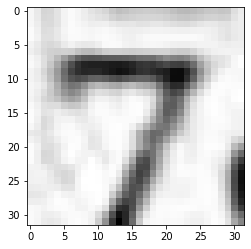

In [9]:
#Let's visualize some numbers using matplotlib
print("Label: {}".format(ytrain[8000]))
plt.imshow(Xtrain[8000], cmap='gray')

Q2. Data pre-processing and visualisation.

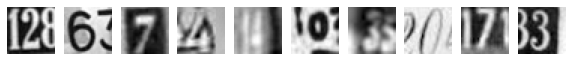

label for each of the above image: [2 6 7 4 4 0 3 0 7 3]


In [10]:
# visualizing the first 10 images in the dataset and their labels
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(Xtrain[i].reshape(32, 32), cmap="gray")
    plt.axis('off')
plt.show()
print('label for each of the above image: %s' % (ytrain[0:10]))

In [11]:
#Reshape the train and test sets into compatible shapes
Xtrain = Xtrain.reshape(Xtrain.shape[0], 32, 32, 1)
Xtest = Xtest.reshape(Xtest.shape[0], 32, 32, 1)
Xval = Xval.reshape(Xval.shape[0], 32, 32, 1)

In [12]:
Xtrain.shape

(42000, 32, 32, 1)

In [13]:
#Normalize the data
Xtrain = Xtrain.astype('float32')
Xtest = Xtest.astype('float32')
Xval = Xval.astype('float32')

Xtrain /= 255
Xtest /= 255
Xval /= 255

In [14]:
#Print shape of data and number of images

print("Xtrain shape:", Xtrain.shape)
print("Images in Xtrain:", Xtrain.shape[0])
print("Images in Xtest:", Xtest.shape[0])
print("Images in XVal:", Xval.shape[0])
print("Max value in Xtrain:", Xtrain.max())
print("Min value in Xtrain:", Xtrain.min())

Xtrain shape: (42000, 32, 32, 1)
Images in Xtrain: 42000
Images in Xtest: 18000
Images in XVal: 60000
Max value in Xtrain: 0.9999
Min value in Xtrain: 0.0


In [15]:
ytrain = to_categorical(ytrain, num_classes=10)
ytest = to_categorical(ytest, num_classes=10)
yval = to_categorical(yval, num_classes=10)

print("Shape of ytrain:", ytrain.shape)
print("One value of ytrain:", ytrain[0])

Shape of ytrain: (42000, 10)
One value of ytrain: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


Q3. Design, train, tune and test a neural network image classifier.

In [16]:
#Model 1: weight - 'he_normal', 'batch normalization', 'dropout', Activation - 'Relu' in hidden layer and 'softmax' in output layer, 3 hidden layers - 200, 100,50 respectively
#optimizer='Adam', learning_rate = 0.001(Default)

def mlp_model():
#Initialize Sequential model
  tf.keras.backend.clear_session()  #clear the model session
  model = Sequential()

#Reshape data from 2D to 1D -> 32x32 to 784
  model.add(tf.keras.layers.Reshape((1024,),input_shape=(32,32,)))

#Normalize the data - BatchNormalization can be applied before any trainable layer
  model.add(tf.keras.layers.BatchNormalization())

#Weight intialization - using "he_normal" technique.
#Dropout range can be from 0.1% to 0.5%
#Add 1st hidden layer
  model.add(tf.keras.layers.Dense(200, input_shape = (1024,), kernel_initializer='he_normal', activation='relu', name='Layer_1'))
  model.add(tf.keras.layers.Dropout(0.4)) #40% dropout rate 


#Add 2nd hidden layer
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.Dense(100, kernel_initializer='he_normal', activation='relu', name='Layer_2'))
  model.add(tf.keras.layers.Dropout(0.3)) #30% dropout rate


#Add 3rd hidden layer
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.Dense(50, kernel_initializer='he_normal', activation='relu', name='Layer_3'))
  model.add(tf.keras.layers.Dropout(0.2)) #20% dropout rate


#Add OUTPUT layer
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.Dense(10, activation='softmax'))

#Adam optimizer with learning rate - .0001
  adam =optimizers.Adam(lr = 0.0001)

#compile the model
  model.compile(optimizer = adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])

  return model

In [17]:
model = mlp_model()
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 1024)              0         
_________________________________________________________________
batch_normalization (BatchNo (None, 1024)              4096      
_________________________________________________________________
Layer_1 (Dense)              (None, 200)               205000    
_________________________________________________________________
dropout (Dropout)            (None, 200)               0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 200)               800       
_________________________________________________________________
Layer_2 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout_1 (Dropout)          (None, 100)               0

In [18]:
#Evaluate and train the model

model_checkpoint = ModelCheckpoint('Auto_vehile.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1, save_freq='epoch')

callback= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

history = model.fit(Xtrain, ytrain,
                    validation_data= (Xtest, ytest),
                    batch_size=32, epochs = 100, 
                    verbose = 1,
                    callbacks=[callback,model_checkpoint])

Epoch 1/100
1313/1313 [==============================] - 8s 5ms/step - loss: 2.7275 - accuracy: 0.1154 - val_loss: 2.1042 - val_accuracy: 0.2685

Epoch 00001: val_accuracy improved from -inf to 0.26850, saving model to Auto_vehile.h5
Epoch 2/100
1313/1313 [==============================] - 7s 5ms/step - loss: 2.3686 - accuracy: 0.1694 - val_loss: 1.8584 - val_accuracy: 0.4039

Epoch 00002: val_accuracy improved from 0.26850 to 0.40389, saving model to Auto_vehile.h5
Epoch 3/100
1313/1313 [==============================] - 7s 5ms/step - loss: 2.1311 - accuracy: 0.2411 - val_loss: 1.6539 - val_accuracy: 0.4974

Epoch 00003: val_accuracy improved from 0.40389 to 0.49739, saving model to Auto_vehile.h5
Epoch 4/100
1313/1313 [==============================] - 7s 5ms/step - loss: 1.9390 - accuracy: 0.3097 - val_loss: 1.4815 - val_accuracy: 0.5847

Epoch 00004: val_accuracy improved from 0.49739 to 0.58467, saving model to Auto_vehile.h5
Epoch 5/100
1313/1313 [==============================] 

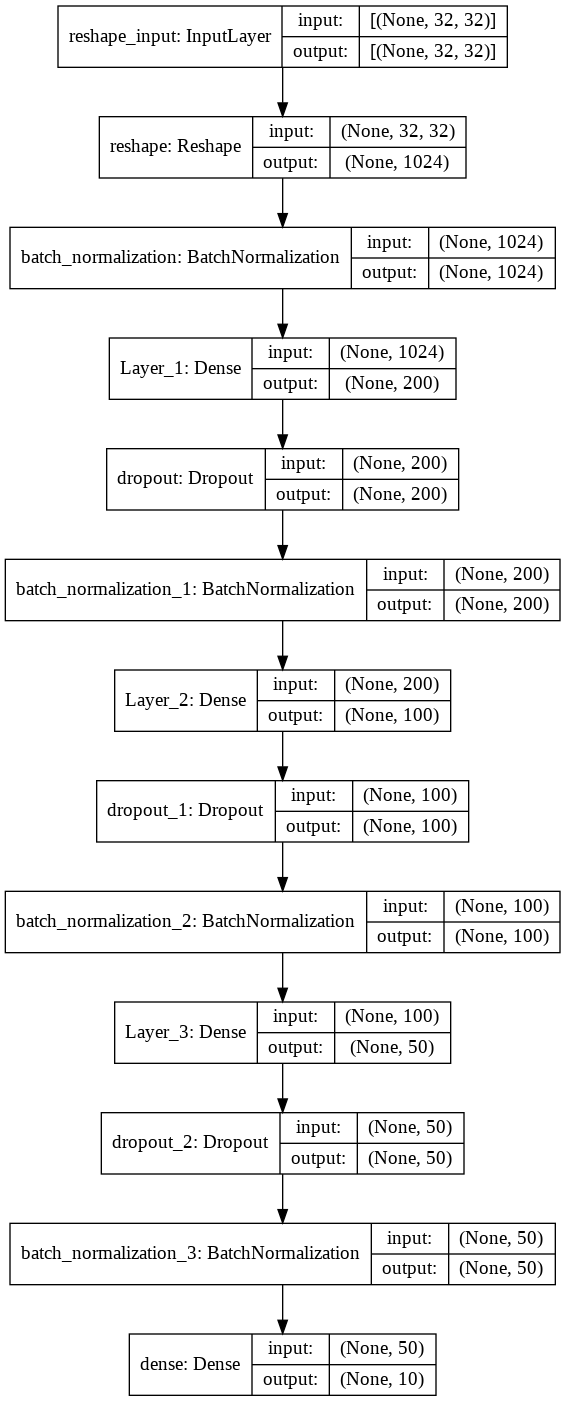

In [19]:
plot_model(model, show_shapes=True, show_layer_names=True)

In [20]:
results = model.evaluate(Xtest, ytest)

563/563 [==============================] - 1s 1ms/step - loss: 0.6062 - accuracy: 0.8372


In [21]:
results_val = model.evaluate(Xval , yval)

1875/1875 [==============================] - 3s 2ms/step - loss: 0.5650 - accuracy: 0.8541


In [23]:
results_train = model.evaluate(Xtrain , ytrain)

1313/1313 [==============================] - 2s 1ms/step - loss: 0.5474 - accuracy: 0.8614


In [24]:
print('Test accuracy: ', results[1])

Test accuracy:  0.8372222185134888


In [25]:
#Building a Batch
input_data = np.expand_dims(Xtest[0], axis=0)
input_data.shape

(1, 32, 32, 1)

In [26]:
#Model Prediction
pred = model.predict(input_data)
pred

array([[0.15379906, 0.08649189, 0.09744173, 0.08410151, 0.10820772,
        0.05799267, 0.08368746, 0.06934042, 0.14466192, 0.11427552]],
      dtype=float32)

In [ ]:
pred.shape

(1, 10)

In [ ]:
pred[0]

array([0.20183681, 0.17154333, 0.1053889 , 0.03982593, 0.09206331,
       0.02759448, 0.06827137, 0.05051199, 0.16224685, 0.08071705],
      dtype=float32)

In [ ]:
#Predicted Class
np.argmax(pred[0])
np.max(pred[0])

0.20183681

In [27]:
#Actual Class
np.argmax(ytest[0])
np.argmax(ytest[0])

1

In [28]:
#Tune the hyperparameters-----
#Model 2: weight - 'GlorotUniform', 'batch normalization',  Activation - 'Relu' in hidden layer and 'softmax' in output layer, 2 hidden layers - 200, 100 respectively,
#optimizer='Adam', learning_rate=0.01 and beta_1=0.9 .

def mlp_model2():
#Initialize Sequential model
  tf.keras.backend.clear_session()  #clear the model session
  model2 = Sequential()

#Reshape data from 2D to 1D -> 32x32 to 1024
  model2.add(tf.keras.layers.Reshape((1024,),input_shape=(32,32,)))

#Normalize the data - BatchNormalization can be applied before any trainable layer
  model2.add(tf.keras.layers.BatchNormalization())

#Weight intialization - using "he_normal" technique.
#Dropout range can be from 0.1% to 0.5%
#Add 1st hidden layer
  initializer = tf.keras.initializers.GlorotUniform()
  model2.add(tf.keras.layers.Dense(200, input_shape = (1024,), kernel_initializer=initializer, activation='relu', name='Layer_1'))
  model2.add(tf.keras.layers.Dropout(0.3)) #30% dropout rate 


#Add 2nd hidden layer
  model2.add(tf.keras.layers.BatchNormalization())
  model2.add(tf.keras.layers.Dense(100, kernel_initializer=initializer, activation='relu', name='Layer_2'))
  model2.add(tf.keras.layers.Dropout(0.2)) #20% dropout rate


#Add 3rd hidden layer
 # model2.add(tf.keras.layers.BatchNormalization())
 # model2.add(tf.keras.layers.Dense(50, kernel_initializer=initializer, activation='relu', name='Layer_3'))
 # model2.add(tf.keras.layers.Dropout(0.1)) #10% dropout rate


#Add OUTPUT layer
  model2.add(tf.keras.layers.BatchNormalization())
  model2.add(tf.keras.layers.Dense(10, activation='softmax'))

#Adam optimizer with learning rate - 0.1
  adam =optimizers.Adam(lr = 0.01, beta_1=0.9)

#compile the model
  model2.compile(optimizer = adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])

  return model2

In [29]:
model_tune = mlp_model2()
model_tune.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 1024)              0         
_________________________________________________________________
batch_normalization (BatchNo (None, 1024)              4096      
_________________________________________________________________
Layer_1 (Dense)              (None, 200)               205000    
_________________________________________________________________
dropout (Dropout)            (None, 200)               0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 200)               800       
_________________________________________________________________
Layer_2 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout_1 (Dropout)          (None, 100)               0

In [30]:
#Evaluate and train the model - Hyper paramter - batch_size=150, epochs = 200

model_checkpoint2 = ModelCheckpoint('Auto_vehile_tune.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1, save_freq='epoch')

callback2= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

history2 = model_tune.fit(Xtrain, ytrain,
                    validation_data= (Xval, yval),
                    batch_size=150, epochs= 200,
                    verbose = 1,
                    callbacks=[callback2,model_checkpoint2])

Epoch 1/200
280/280 [==============================] - 4s 13ms/step - loss: 2.0577 - accuracy: 0.2866 - val_loss: 1.1905 - val_accuracy: 0.6408

Epoch 00001: val_accuracy improved from -inf to 0.64078, saving model to Auto_vehile_tune.h5
Epoch 2/200
280/280 [==============================] - 3s 12ms/step - loss: 1.1630 - accuracy: 0.6266 - val_loss: 0.8101 - val_accuracy: 0.7527

Epoch 00002: val_accuracy improved from 0.64078 to 0.75275, saving model to Auto_vehile_tune.h5
Epoch 3/200
280/280 [==============================] - 3s 12ms/step - loss: 0.9946 - accuracy: 0.6860 - val_loss: 0.7063 - val_accuracy: 0.7817

Epoch 00003: val_accuracy improved from 0.75275 to 0.78167, saving model to Auto_vehile_tune.h5
Epoch 4/200
280/280 [==============================] - 3s 12ms/step - loss: 0.9162 - accuracy: 0.7094 - val_loss: 0.7312 - val_accuracy: 0.7784

Epoch 00004: val_accuracy did not improve from 0.78167
Epoch 5/200
280/280 [==============================] - 3s 12ms/step - loss: 0.85

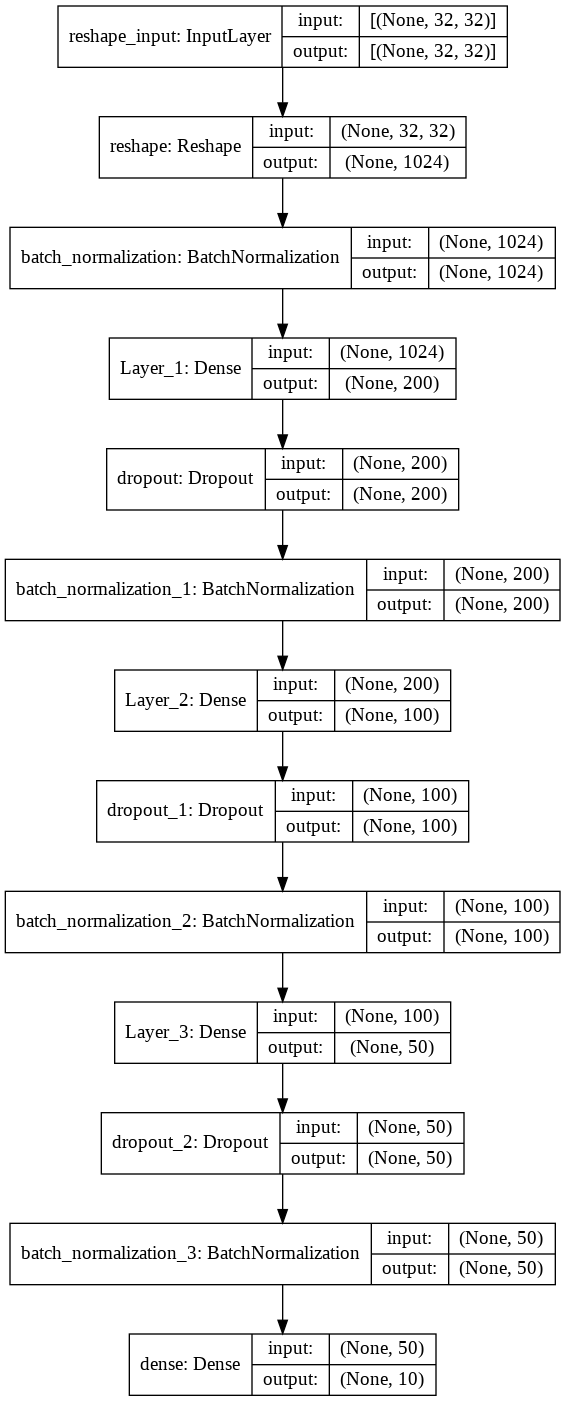

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True)

In [31]:
results2 = model_tune.evaluate(Xtest, ytest)

563/563 [==============================] - 1s 2ms/step - loss: 0.4676 - accuracy: 0.8575


In [32]:
results2_val = model_tune.evaluate(Xval, yval)

1875/1875 [==============================] - 4s 2ms/step - loss: 0.3754 - accuracy: 0.8858


In [33]:
results2_train = model_tune.evaluate(Xtrain, ytrain)

1313/1313 [==============================] - 3s 2ms/step - loss: 0.3359 - accuracy: 0.8980


In [34]:
print('Test accuracy: ', results2[1])

Test accuracy:  0.8575000166893005


Good default settings for the tested machine learning problems are alpha=0.001, beta1=0.9, beta2=0.999 and epsilon=10−8

TensorFlow: learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-08.
Keras: lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0.

#4. Plot the training loss, validation loss vs number of epochs and training accuracy, validation accuracy vs number of epochs plot and write your observations on the same.

OBSERVATION:
From the below plot, it is observed that the Training and testing loss is decreased and Auccracy is increased over number of Epochs which tells us the Model is trained better over number of iterations.

After tuning the hyper parameters, the model accuracy has been improved and th validation loss is decreased over the number of Epochs- as shown in Model 2 graph.

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


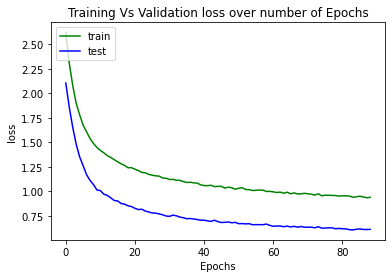

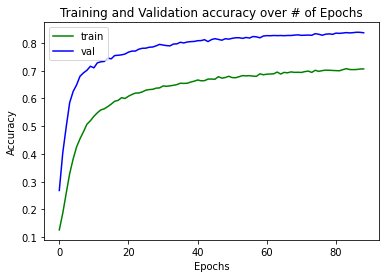

In [36]:
# list all data in history
print(history.history.keys())

# summarize history for loss
plt.plot(history.history['loss'],'g', label='Training loss' )
plt.plot(history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training Vs Validation loss over number of Epochs')
plt.ylabel('loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for accuracy
plt.plot(history.history['accuracy'], 'g', label='Training accuracy')
plt.plot(history.history['val_accuracy'], 'b', label='validation accuracy')
plt.title('Training and Validation accuracy over # of Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


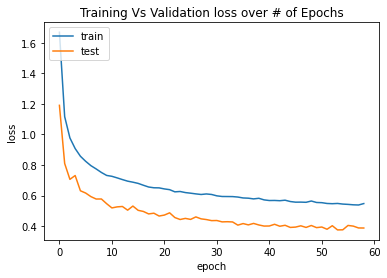

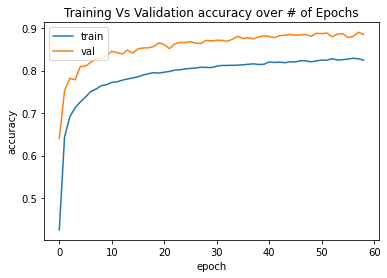

In [37]:
# list all data in history
print(history.history.keys())

# summarize history for loss - 2nd model
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Training Vs Validation loss over # of Epochs')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


# summarize history for accuracy - 2nd model
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Training Vs Validation accuracy over # of Epochs')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()